In [1]:
"""
Demonstration of my UniversalClassifier wrapper, based on Scikit-Learn and cuML and
supporting GPU
"""
import warnings
import pandas as pd
from matplotlib import pyplot as plt
from ac.ml.classification import UniversalClassifier
from ac.tabular import Report

warnings.filterwarnings("ignore")


/home/ac87/miniconda3/envs/rapids-24-12/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
"""
Loading a scraped dataset containing data about the top 500 billionaires in the world: region, wealth and industry sector. The non-numerical columns have already been mapped.
"""
billionaires = pd.read_csv(".data/billionaires.csv")
billionaires.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rank            499 non-null    int64  
 1   Name            499 non-null    object 
 2   Wealth          499 non-null    float64
 3   Country         499 non-null    object 
 4   Sector          499 non-null    object 
 5   Region          499 non-null    object 
 6   Mapped_Region   499 non-null    float64
 7   Mapped_Country  499 non-null    float64
 8   Mapped_Sector   499 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 35.2+ KB


In [3]:
"""
Let's define a "sample", the 501st richest man in the world, and let's see which algorithm
predicts his country the best
"""
algorithms   = ["decisiontree", "randomforest", "svm"]
columns      = ["Wealth", "Mapped_Region", "Mapped_Country", "Mapped_Sector"]
sample       = [80, 1.0, 3.0]

In [4]:
"""
UniversalClassifier explores authomatically the optimal hyperparameter configuration.
Let's define the hyperparameter range
"""
grids = {
    "decisiontree": {
        "max_depth": [1, 2, 4, 8, 16, 32],
        "min_samples_leaf": [1, 2, 3, 4, 5],
        "criterion": ["gini", "entropy", "log_loss"],
    },
    "randomforest": {
        "max_depth": [1, 2, 4, 8, 16, 32],
        "min_samples_leaf": [1, 2, 3, 4, 5],
        "criterion": ["gini", "entropy", "log_loss"],
    }
}

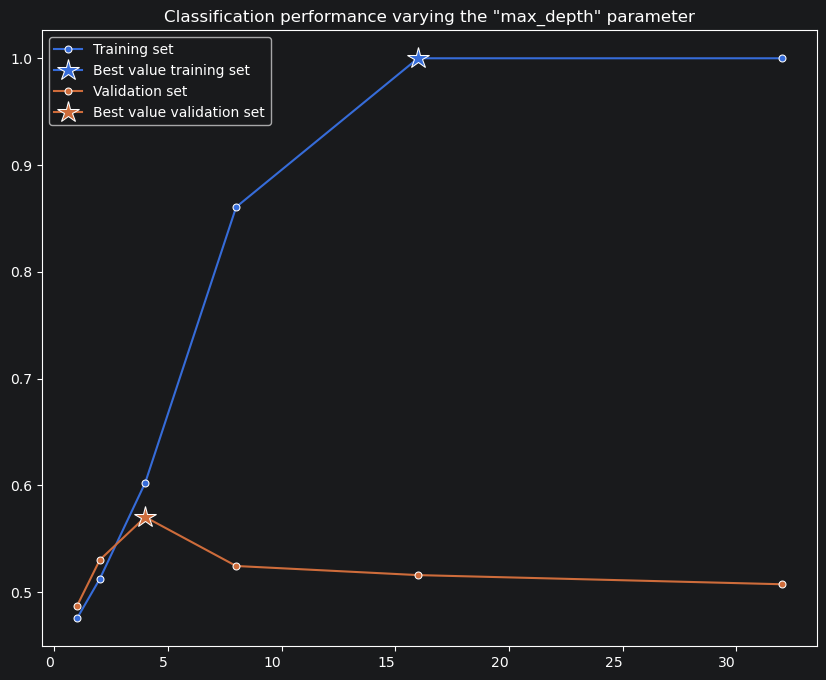

convert /home/ac87/PycharmProjects/DMML/reports/pdf/decisiontree.html as a Writer/Web document -> /home/ac87/PycharmProjects/DMML/reports/pdf/decisiontree.pdf using filter : writer_web_pdf_Export
Overwriting: /home/ac87/PycharmProjects/DMML/reports/pdf/decisiontree.pdf


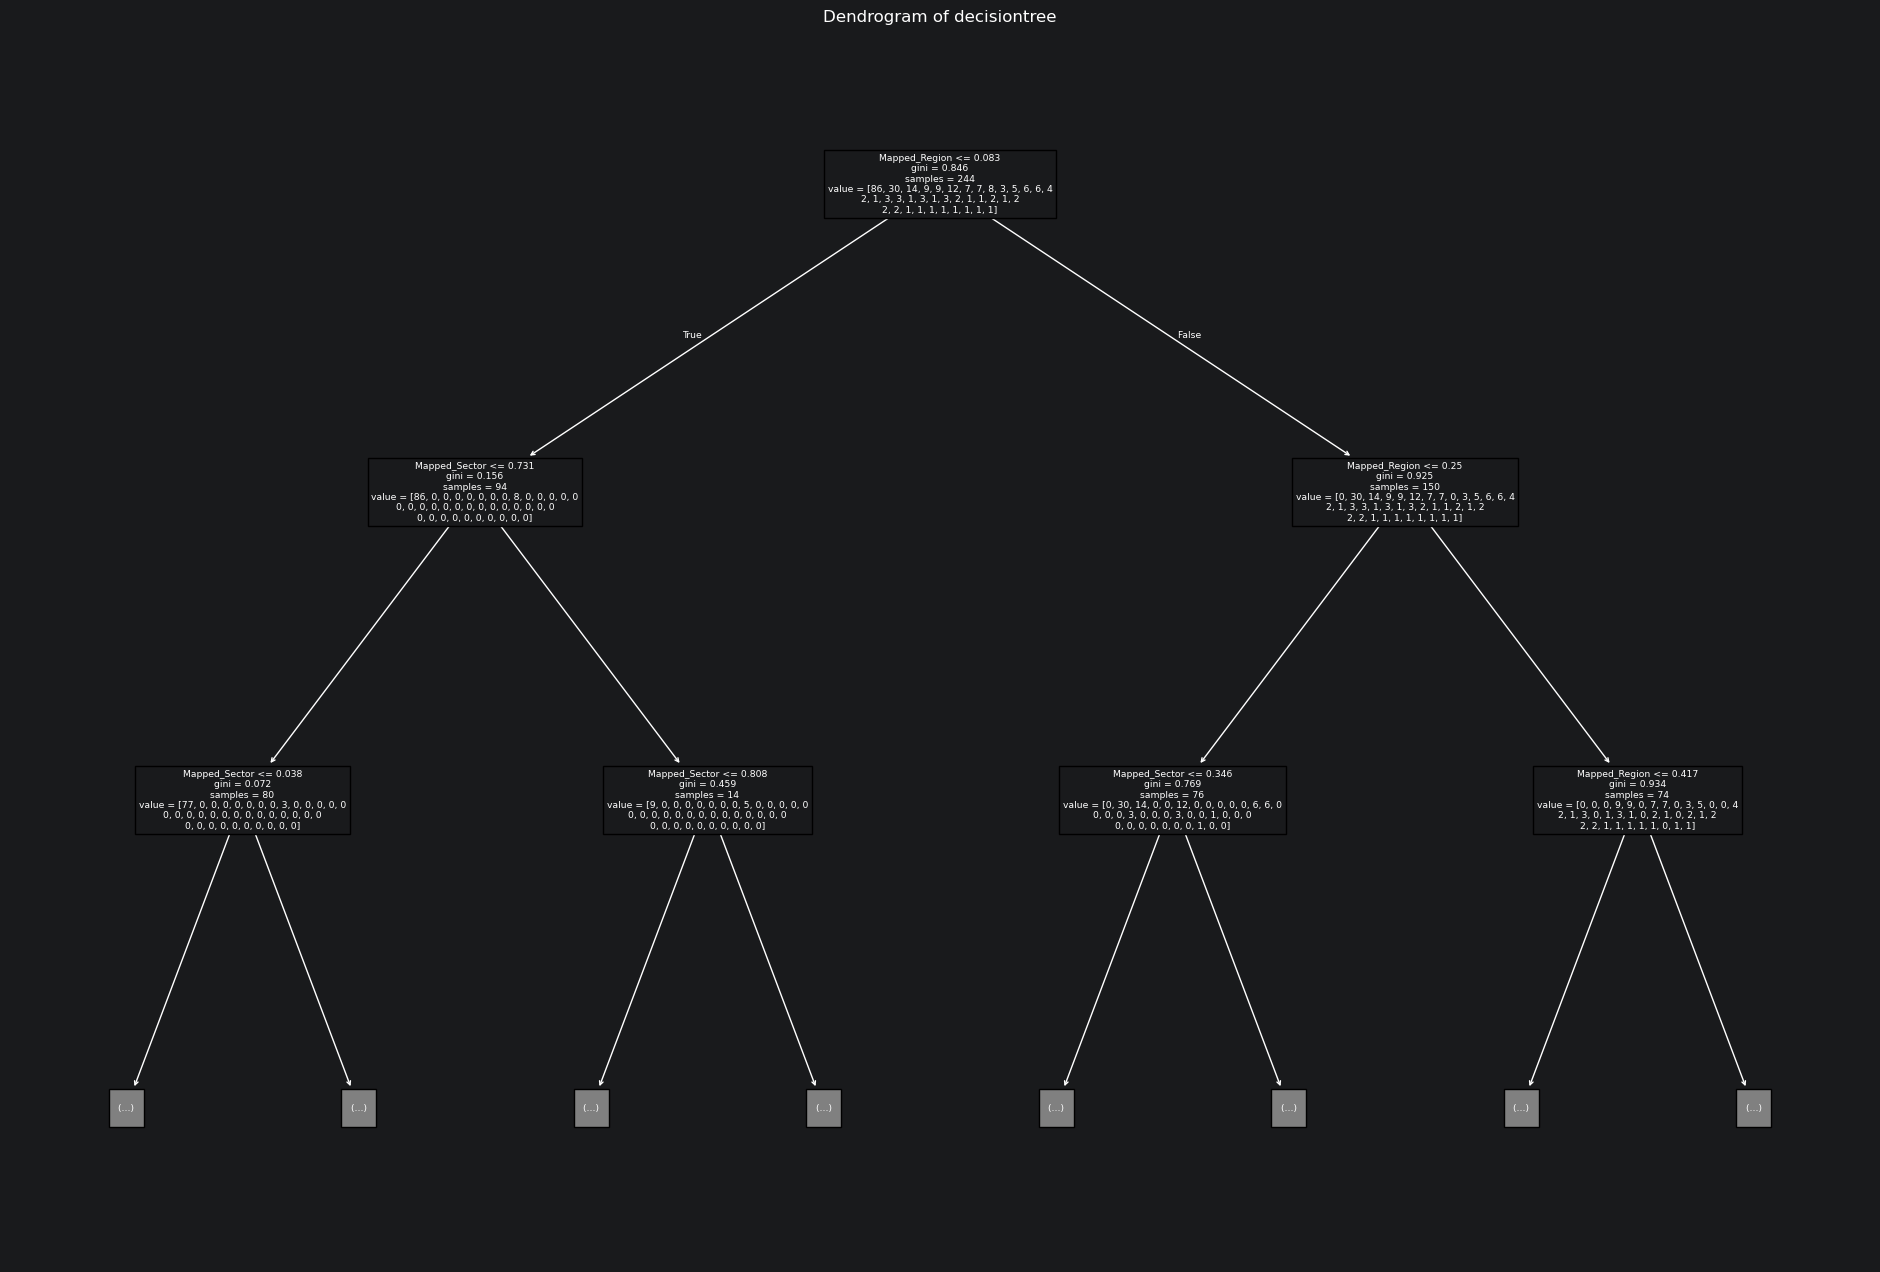

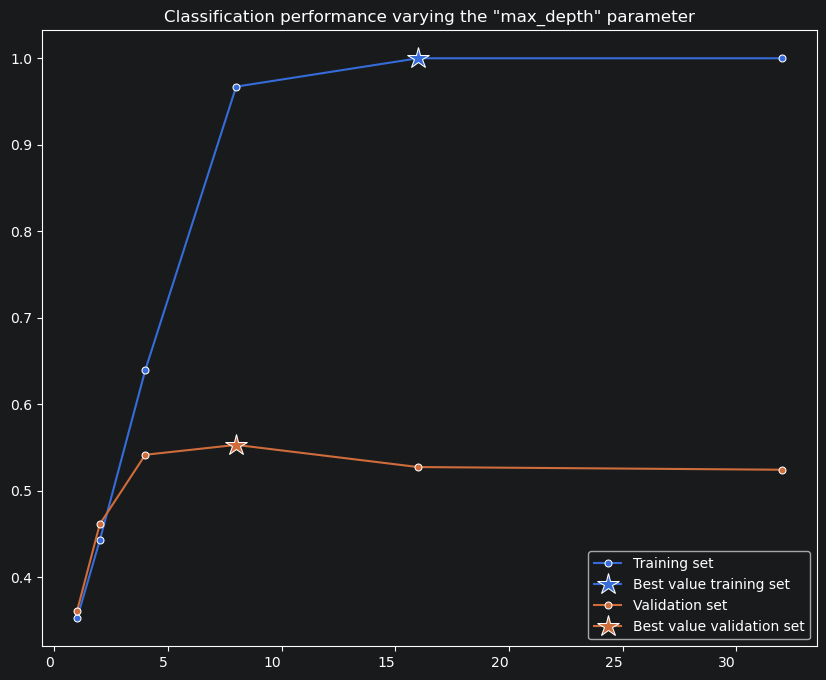

convert /home/ac87/PycharmProjects/DMML/reports/pdf/randomforest.html as a Writer/Web document -> /home/ac87/PycharmProjects/DMML/reports/pdf/randomforest.pdf using filter : writer_web_pdf_Export
Overwriting: /home/ac87/PycharmProjects/DMML/reports/pdf/randomforest.pdf


convert /home/ac87/PycharmProjects/DMML/reports/pdf/svm.html as a Writer/Web document -> /home/ac87/PycharmProjects/DMML/reports/pdf/svm.pdf using filter : writer_web_pdf_Export
Overwriting: /home/ac87/PycharmProjects/DMML/reports/pdf/svm.pdf


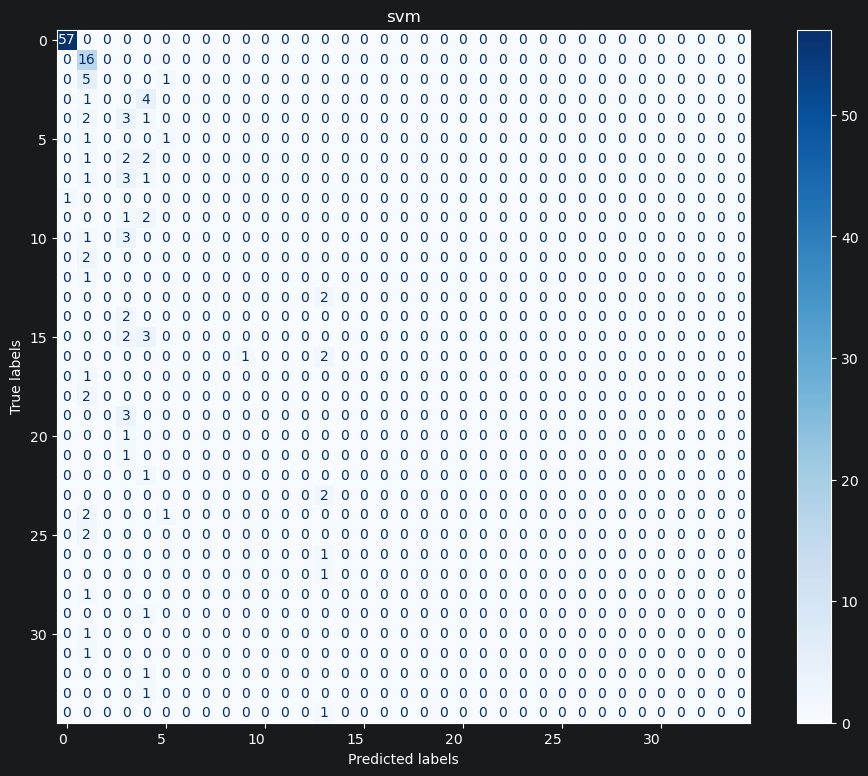

In [5]:
"""
Launching the classification task. This cell demonstrates also my Report class,
which allows the generation of simple reports from tabular data in different document
formats.
"""
for algorithm in algorithms:
    uc = UniversalClassifier(method=algorithm, data=billionaires, subset=columns, target="Mapped_Country")
    uc.split(ratio="30%")

    # Exploring different configurations with cross-validation
    param_grid = grids.get(algorithm, None)
    if param_grid is not None:
        uc.explore(param=param_grid, cv=5)

    # Fitting ad performing cross-validation
    uc.fit(cv=5)
    predicted = uc.predict(sample)

    # Plotting the algorithm performance
    if param_grid is not None:
        uc.draw("performance", figsize=(10, 8), rotation=90)
        plt.show()

    # Generating some textual reports
    results = uc.evaluate("scores")
    title = "Scores of " + algorithm
    report = Report()
    report.set(source=results, head="Scores")
    report.headline(title)
    report.textualize()

    if algorithm != "svm":
        results = uc.evaluate("params")
        title = "Parameter values of " + algorithm
        report.set(source=results, head="Parameters")
        report.headline(title)
        report.textualize()

    # Saving everything in pdf
    report.dump(report_name=algorithm, extension=".pdf")

    # Drawing the confusion matrix
    uc.draw(what="confusion", set="test", title=algorithm, show=True)

    # Dendrogram
    if algorithm == "decisiontree":
        uc.draw(
            what="tree",
            title="Dendrogram of " + algorithm,
            max_depth=2,
            figsize=(24, 16),
            show=True
        )